In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("/content/Student Depression Dataset.csv")

In [3]:
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [4]:
df.shape

(27901, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [6]:
df.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27898.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,3.139867,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,1.437347,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,2.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000


In [7]:
df.drop(
    columns=[
        "id",
        "City",
        "Work Pressure",
        "Job Satisfaction"
    ],
    inplace=True,
    errors="ignore"
)

In [8]:
df.columns

Index(['Gender', 'Age', 'Profession', 'Academic Pressure', 'CGPA',
       'Study Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')

In [9]:
df.isnull().sum()

,0
Gender,0
Age,0
Profession,0
Academic Pressure,0
CGPA,0
Study Satisfaction,0
Sleep Duration,0
Dietary Habits,0
Degree,0
Have you ever had suicidal thoughts ?,0


In [10]:
df["Financial Stress"] = df["Financial Stress"].fillna(df["Financial Stress"].median())

In [11]:
df.isnull().sum()

,0
Gender,0
Age,0
Profession,0
Academic Pressure,0
CGPA,0
Study Satisfaction,0
Sleep Duration,0
Dietary Habits,0
Degree,0
Have you ever had suicidal thoughts ?,0


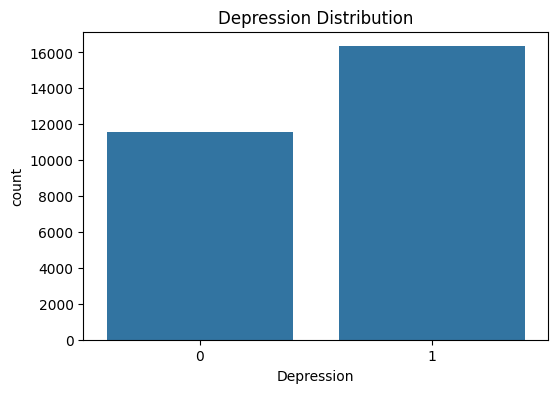

Depression
1    16336
0    11565
Name: count, dtype: int64


In [12]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Depression")

plt.title("Depression Distribution")
plt.show()

print(df["Depression"].value_counts())

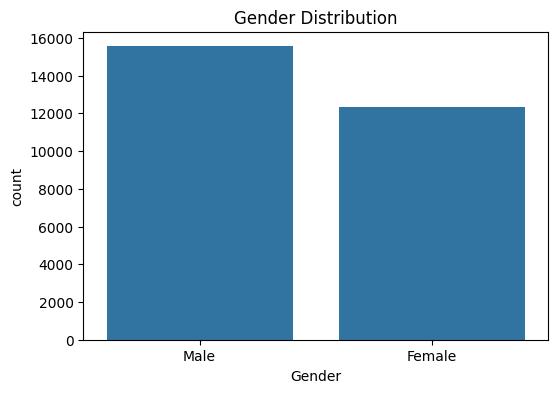

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Gender")

plt.title("Gender Distribution")
plt.show()

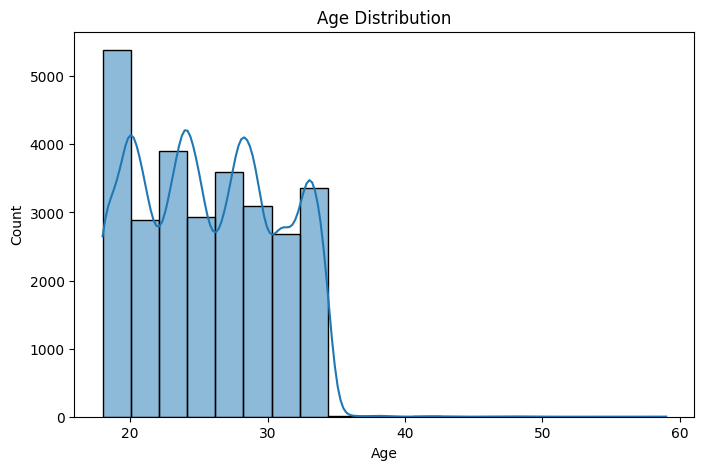

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Age Distribution")
plt.show()

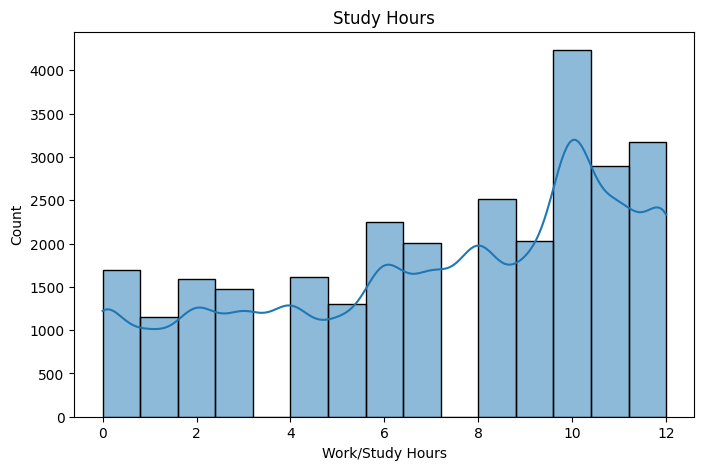

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df["Work/Study Hours"], bins=15, kde=True)

plt.title("Study Hours")
plt.show()

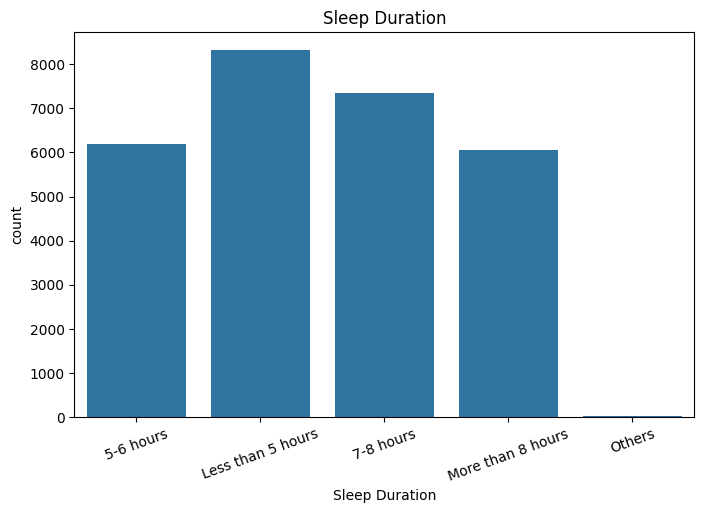

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Sleep Duration")

plt.title("Sleep Duration")
plt.xticks(rotation=20)

plt.show()

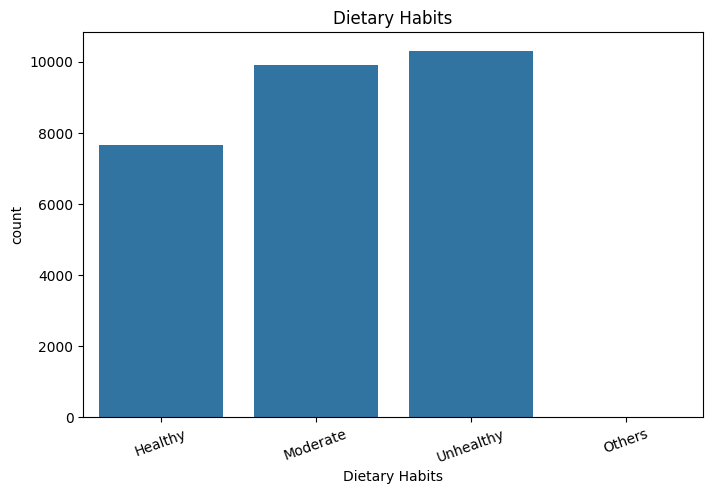

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Dietary Habits")

plt.title("Dietary Habits")

plt.xticks(rotation=20)

plt.show()

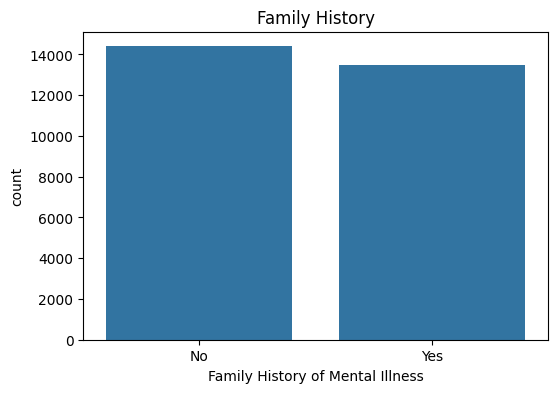

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Family History of Mental Illness"
)

plt.title("Family History")

plt.show()

In [19]:
print(df["Depression"].isnull().sum())
print(df["Depression"].dtype)
print(df["Depression"].unique())
print(df["Depression"].value_counts(dropna=False))

0
int64
[1 0]
Depression
1    16336
0    11565
Name: count, dtype: int64


In [20]:

X = df.drop(columns=["Depression"])
y = df["Depression"]
X = pd.get_dummies(X, drop_first=True)


print("X shape:", X.shape)
print("y shape:", y.shape)
print("Missing in X:", X.isnull().sum().sum())
print("Missing in y:", y.isnull().sum())

X shape: (27901, 56)
y shape: (27901,)
Missing in X: 0
Missing in y: 0


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Done")

Done


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Accuracy : 0.8450098548647196
Precision: 0.858763810092565
Recall   : 0.8800489596083231
F1 Score : 0.8692761069971287


In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81      2313
           1       0.86      0.88      0.87      3268

    accuracy                           0.85      5581
   macro avg       0.84      0.84      0.84      5581
weighted avg       0.84      0.85      0.84      5581



In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [27]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Accuracy : 0.8392761153915069
Precision: 0.8506359065365277
Recall   : 0.8800489596083231
F1 Score : 0.8650924951120469


In [28]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [29]:
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))

Accuracy : 0.8382010392402796
Precision: 0.8516205768658935
Recall   : 0.8763769889840881
F1 Score : 0.8638214447293018


In [30]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [0.8455, 0.8384, 0.8407],
    "Precision": [0.8591, 0.8508, 0.8529],
    "Recall": [0.8807, 0.8779, 0.8797],
    "F1-Score": [0.8697, 0.8642, 0.8661]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8455,0.8591,0.8807,0.8697
1,Random Forest,0.8384,0.8508,0.8779,0.8642
2,XGBoost,0.8407,0.8529,0.8797,0.8661


In [68]:
import gradio as gr

theme = gr.themes.Soft(
    primary_hue="blue",
    secondary_hue="emerald",
    neutral_hue="slate",
)

css = """
body{
    background:#0f172a;
}

.gradio-container{
    max-width:1100px !important;
    margin:auto;
    background:#0f172a !important;
    color:white !important;
}

footer{
    display:none;
}

/* Cards */
.gr-group{
    background:#1e293b !important;
    border:1px solid #334155 !important;
    border-radius:18px !important;
    padding:18px !important;
    margin-bottom:18px !important;
}

/* Header */
h1{
    color:#60a5fa !important;
    text-align:center;
}

h2,h3{
    color:#f8fafc !important;
}

p{
    color:#cbd5e1 !important;
}

/* Labels */
label{
    color:white !important;
    font-weight:600 !important;
}

/* Inputs */
input,
textarea{
    background:#1e293b !important;
    color:white !important;
    border:1px solid #475569 !important;
    border-radius:10px !important;
}

/* Dropdown */
select{
    background:#1e293b !important;
    color:white !important;
    border-radius:10px !important;
}

/* Slider */
.gr-slider{
    accent-color:#3b82f6;
}

/* Button */
button{
    background:linear-gradient(90deg,#2563eb,#06b6d4) !important;
    color:white !important;
    border:none !important;
    border-radius:12px !important;
    font-size:18px !important;
    font-weight:bold !important;
    transition:.3s;
}

button:hover{
    transform:scale(1.03);
    box-shadow:0 0 18px rgba(37,99,235,.5);
}

/* Result Box */
textarea{
    font-size:16px !important;
    line-height:1.7 !important;
}

/* Scrollbar */
::-webkit-scrollbar{
    width:8px;
}

::-webkit-scrollbar-thumb{
    background:#475569;
    border-radius:10px;
}
"""

with gr.Blocks(theme=theme, css=css) as demo:

    gr.HTML("""
    <div style='text-align:center;padding:20px'>
        <h1>Student Depression Prediction</h1>
        <h3>AI-Based Mental Health Screening System</h3>
        <p style='color:gray'>
        Enter the student's information and click Predict.
        </p>
    </div>
    """)

    with gr.Group():
        gr.Markdown("## Personal Information")

        with gr.Row():
            gender = gr.Dropdown(
                ["Male","Female"],
                label="Gender"
            )

            age = gr.Number(
                label="Age"
            )

    with gr.Group():
        gr.Markdown("## Academic Information")

        with gr.Row():

            academic_pressure = gr.Slider(
                0,5,
                step=1,
                label="Academic Pressure"
            )

            cgpa = gr.Number(
                label="CGPA"
            )

        with gr.Row():

            study_satisfaction = gr.Slider(
                0,5,
                step=1,
                label="Study Satisfaction"
            )

            work_hours = gr.Number(
                label="Work / Study Hours"
            )

        degree = gr.Dropdown(
            sorted(df["Degree"].unique().tolist()),
            label="Degree"
        )

    with gr.Group():
        gr.Markdown("## Lifestyle")

        with gr.Row():

            sleep = gr.Dropdown(
                [
                    "Less than 5 hours",
                    "5-6 hours",
                    "7-8 hours",
                    "More than 8 hours"
                ],
                label="Sleep Duration"
            )

            diet = gr.Dropdown(
                [
                    "Healthy",
                    "Moderate",
                    "Unhealthy"
                ],
                label="Dietary Habits"
            )

    with gr.Group():
        gr.Markdown("## Mental Health")

        with gr.Row():

            suicidal = gr.Dropdown(
                ["Yes","No"],
                label="Suicidal Thoughts"
            )

            family = gr.Dropdown(
                ["Yes","No"],
                label="Family History"
            )

        financial = gr.Slider(
            0,
            5,
            step=1,
            label="Financial Stress"
        )

    predict_btn = gr.Button(
        "Predict Depression",
        variant="primary",
        size="lg"
    )

    result = gr.Textbox(
        label="Prediction Result",
        lines=10,
        interactive=False
    )

    predict_btn.click(
        fn=predict_depression,
        inputs=[
            gender,
            age,
            academic_pressure,
            cgpa,
            study_satisfaction,
            sleep,
            diet,
            degree,
            suicidal,
            work_hours,
            financial,
            family
        ],
        outputs=result
    )

demo.launch()

/tmp/ipykernel_949/3274713198.py:108: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=theme, css=css) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0c69c4e3d80687bf33.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
